In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("crop_yield.csv")

print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())
df.groupby('Crop')['Yield'].mean()

           Crop  Crop_Year       Season  State     Area  Annual_Rainfall  \
0      Arecanut       1997  Whole Year   Assam  73814.0           2051.4   
1     Arhar/Tur       1997  Kharif       Assam   6637.0           2051.4   
2   Castor seed       1997  Kharif       Assam    796.0           2051.4   
3      Coconut        1997  Whole Year   Assam  19656.0           2051.4   
4  Cotton(lint)       1997  Kharif       Assam   1739.0           2051.4   

   Fertilizer  Pesticide     Yield  Avg_Temperature  
0  7024878.38   22882.34     0.796           23.692  
1   631643.29    2057.47     0.710           23.692  
2    75755.32     246.76     0.238           23.692  
3  1870661.52    6093.36  5238.052           23.692  
4   165500.63     539.09     0.421           23.692  
(19689, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   C

Crop
Arecanut                    2.073617
Arhar/Tur                   0.967343
Bajra                       2.427456
Banana                     26.851143
Barley                      1.595525
Black pepper                0.829635
Cardamom                    0.168405
Cashewnut                   3.120455
Castor seed                 0.693623
Coconut                  8652.000215
Coriander                   0.648186
Cotton(lint)                1.797042
Cowpea(Lobia)               0.813224
Dry chillies                2.078356
Garlic                      4.544880
Ginger                      6.442226
Gram                        0.876471
Groundnut                   1.360988
Guar seed                   0.951825
Horse-gram                  0.462830
Jowar                       1.072499
Jute                        7.555398
Khesari                     0.788920
Linseed                     0.473932
Maize                       3.427209
Masoor                      0.703111
Mesta                       5.389

In [3]:
df['Yield'] = df['Yield'].apply(lambda x: x * 1000 if x < 100 else x)

print(df['Yield'].describe())

count    19689.000000
mean      4103.155895
std      10506.908798
min          0.000000
25%        597.000000
50%       1026.000000
75%       2364.000000
max      99782.000000
Name: Yield, dtype: float64


In [4]:
df = pd.get_dummies(df, columns=['Crop', 'State', 'Season'])

print(df.shape)

(19689, 98)


In [5]:
X = df.drop('Yield', axis=1)
y = df['Yield']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(15751, 97) (3938, 97)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

LINEAR REGRESSION
MAE: 2515.8877643822484
MSE: 33790790.42111228
RMSE: 5812.984639676272
R2: 0.7003404604639688


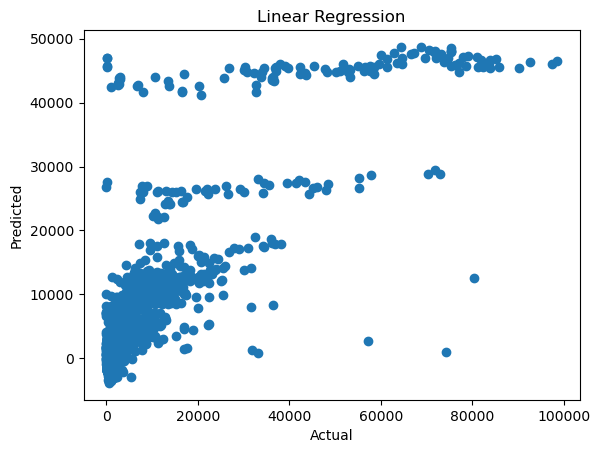

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("LINEAR REGRESSION")
print("MAE:", mae_lr)
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

# Excel
lr_df = X_test.copy()
lr_df['Actual_Yield'] = y_test
lr_df['Predicted_LR'] = y_pred_lr
lr_df.to_excel("Linear_Regression_Output.xlsx", index=False)

# Graph
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression")
plt.show()


DECISION TREE
MAE: 830.0734118842051
MSE: 14165134.633207899
RMSE: 3763.6597392973636
R2: 0.8743824080835678


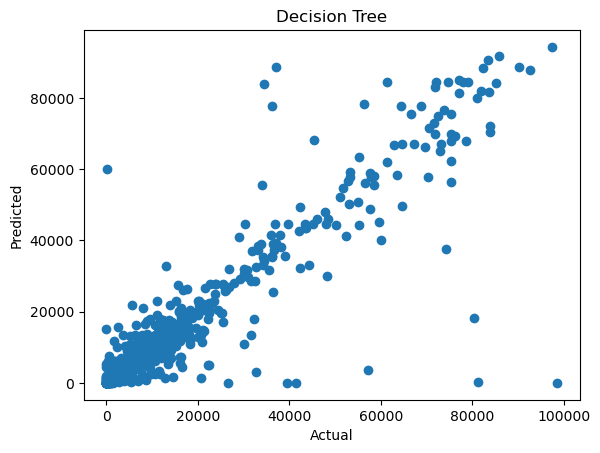

In [9]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("\nDECISION TREE")
print("MAE:", mae_dt)
print("MSE:", mse_dt)
print("RMSE:", rmse_dt)
print("R2:", r2_dt)

# Excel
dt_df = X_test.copy()
dt_df['Actual_Yield'] = y_test
dt_df['Predicted_DT'] = y_pred_dt
dt_df.to_excel("Decision_Tree_Output.xlsx", index=False)

# Graph
plt.scatter(y_test, y_pred_dt)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Decision Tree")
plt.show()


RANDOM FOREST
MAE: 708.5253443905536
MSE: 7494113.160493148
RMSE: 2737.537791610035
R2: 0.9335415812735414


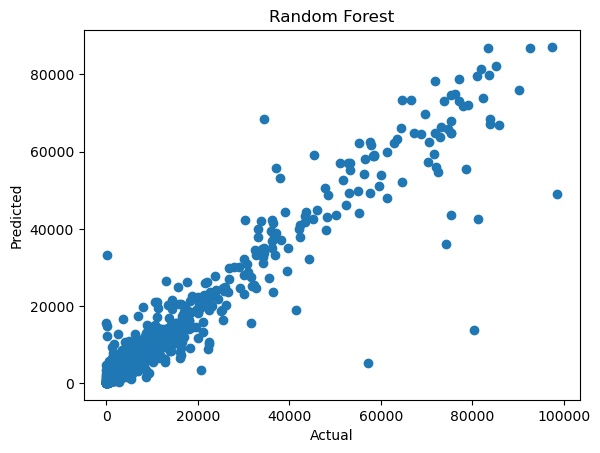

In [10]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRANDOM FOREST")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

# Excel
rf_df = X_test.copy()
rf_df['Actual_Yield'] = y_test
rf_df['Predicted_RF'] = y_pred_rf
rf_df.to_excel("Random_Forest_Output.xlsx", index=False)

# Graph
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest")
plt.show()


SVR
MAE: 3140.7002300888494
MSE: 114691912.73644347
RMSE: 10709.43101833349
R2: -0.017097420060232738


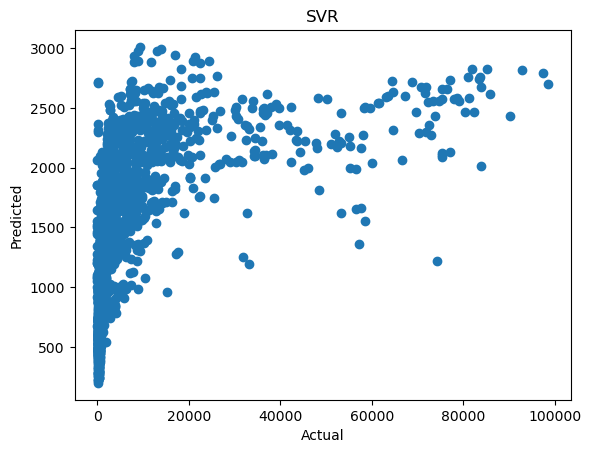

In [64]:
from sklearn.svm import SVR

svr = SVR(C=10, gamma='scale', kernel='rbf')
svr.fit(X_train_scaled, y_train)

y_pred_svr = svr.predict(X_test_scaled)

mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("\nSVR")
print("MAE:", mae_svr)
print("MSE:", mse_svr)
print("RMSE:", rmse_svr)
print("R2:", r2_svr)

# Excel
svr_df = X_test.copy()
svr_df['Actual_Yield'] = y_test
svr_df['Predicted_SVR'] = y_pred_svr
svr_df.to_excel("SVR_Output.xlsx", index=False)

# Graph
plt.scatter(y_test, y_pred_svr)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("SVR")
plt.show()

           Model        R2          MAE         RMSE
0         Linear  0.700340  2515.887764  5812.984640
1  Decision Tree  0.874382   830.073412  3763.659739
2  Random Forest  0.933542   708.525344  2737.537792


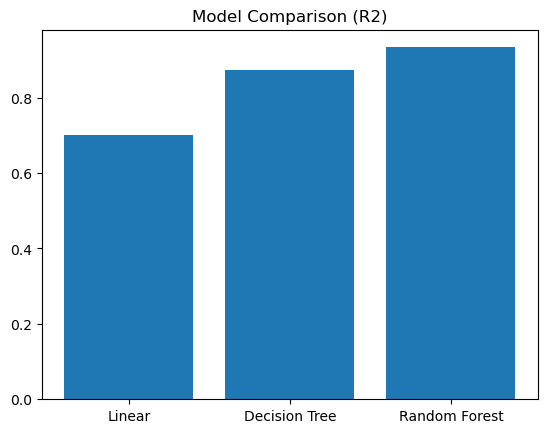

In [11]:
results = pd.DataFrame({
    'Model': ['Linear', 'Decision Tree', 'Random Forest'],
    'R2': [r2_lr, r2_dt, r2_rf],
    'MAE': [mae_lr, mae_dt, mae_rf],
    'RMSE': [rmse_lr, rmse_dt, rmse_rf]
})

print(results)

results.to_excel("Model_Comparison.xlsx", index=False)

# Graph
plt.bar(results['Model'], results['R2'])
plt.title("Model Comparison (R2)")
plt.show()

In [12]:
print(X.columns)

Index(['Crop_Year', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide',
       'Avg_Temperature', 'Crop_Arecanut', 'Crop_Arhar/Tur', 'Crop_Bajra',
       'Crop_Banana', 'Crop_Barley', 'Crop_Black pepper', 'Crop_Cardamom',
       'Crop_Cashewnut', 'Crop_Castor seed', 'Crop_Coconut ', 'Crop_Coriander',
       'Crop_Cotton(lint)', 'Crop_Cowpea(Lobia)', 'Crop_Dry chillies',
       'Crop_Garlic', 'Crop_Ginger', 'Crop_Gram', 'Crop_Groundnut',
       'Crop_Guar seed', 'Crop_Horse-gram', 'Crop_Jowar', 'Crop_Jute',
       'Crop_Khesari', 'Crop_Linseed', 'Crop_Maize', 'Crop_Masoor',
       'Crop_Mesta', 'Crop_Moong(Green Gram)', 'Crop_Moth', 'Crop_Niger seed',
       'Crop_Oilseeds total', 'Crop_Onion', 'Crop_Other  Rabi pulses',
       'Crop_Other Cereals', 'Crop_Other Kharif pulses',
       'Crop_Other Summer Pulses', 'Crop_Peas & beans (Pulses)', 'Crop_Potato',
       'Crop_Ragi', 'Crop_Rapeseed &Mustard', 'Crop_Rice', 'Crop_Safflower',
       'Crop_Sannhamp', 'Crop_Sesamum', 'Crop_Small mi

In [67]:
# Step 1: Input data (Gram)
input_data = {
    'Crop': 'Gram',
    'Season': 'Rabi',
    'State': 'Madhya Pradesh',
    'Crop_Year': 2017,
    'Area': 3000,
    'Annual_Rainfall': 600,
    'Fertilizer': 40000,
    'Pesticide': 100,
    'Avg_Temperature': 22
}

# Step 2: Convert to DataFrame
input_df = pd.DataFrame([input_data])

# Step 3: Apply same encoding as training
input_df = pd.get_dummies(input_df)

# Step 4: Match training columns
input_df = input_df.reindex(columns=X.columns, fill_value=0)

# Step 5: Prediction
prediction = rf.predict(input_df)

# Step 6: Output
print("🌱 Gram Yield (kg/ha):", prediction[0])

🌱 Gram Yield (kg/ha): 788.24


In [68]:
# Step 1: Input data (Maize)
input_data = {
    'Crop': 'Maize',
    'Season': 'Kharif',
    'State': 'Karnataka',
    'Crop_Year': 2018,
    'Area': 4000,
    'Annual_Rainfall': 900,
    'Fertilizer': 80000,
    'Pesticide': 150,
    'Avg_Temperature': 26
}

# Step 2: Convert to DataFrame
input_df = pd.DataFrame([input_data])

# Step 3: Apply same encoding as training
input_df = pd.get_dummies(input_df)

# Step 4: Match training columns (VERY IMPORTANT)
input_df = input_df.reindex(columns=X.columns, fill_value=0)

# Step 5: Prediction
prediction = rf.predict(input_df)

# Step 6: Output
print("🌽 Maize Yield (kg/ha):", prediction[0])

🌽 Maize Yield (kg/ha): 3404.96


In [11]:
def predict_yield(input_data):
    input_df = pd.DataFrame([input_data])
    input_df = pd.get_dummies(input_df)
    input_df = input_df.reindex(columns=X.columns, fill_value=0)
    
    prediction = rf.predict(input_df)
    return prediction[0]

In [70]:
wheat = {
    'Crop': 'Wheat',
    'Season': 'Rabi',
    'State': 'Punjab',
    'Crop_Year': 2018,
    'Area': 5000,
    'Annual_Rainfall': 1200,
    'Fertilizer': 150000,
    'Pesticide': 300,
    'Avg_Temperature': 22
}

print("Wheat Yield:", predict_yield(wheat))

Wheat Yield: 1657.22


In [71]:
maize = {
    'Crop': 'Maize',
    'Season': 'Kharif',
    'State': 'Karnataka',
    'Crop_Year': 2018,
    'Area': 4000,
    'Annual_Rainfall': 900,
    'Fertilizer': 80000,
    'Pesticide': 150,
    'Avg_Temperature': 26
}

print("Maize Yield:", predict_yield(maize))

Maize Yield: 3404.96


In [72]:
gram = {
    'Crop': 'Gram',
    'Season': 'Rabi',
    'State': 'Madhya Pradesh',
    'Crop_Year': 2017,
    'Area': 3000,
    'Annual_Rainfall': 600,
    'Fertilizer': 40000,
    'Pesticide': 100,
    'Avg_Temperature': 22
}

print("Gram Yield:", predict_yield(gram))

Gram Yield: 788.24


In [73]:
rice_wb = {
    'Crop': 'Rice',
    'Season': 'Kharif',
    'State': 'West Bengal',
    'Crop_Year': 2019,
    'Area': 5000,                
    'Annual_Rainfall': 1600,     
    'Fertilizer': 900000,        
    'Pesticide': 2500,           
    'Avg_Temperature': 28        
}

print("Rice Yield:", predict_yield(rice_wb))

Rice Yield: 3161.06


In [12]:
wheat_mp_2026 = {
    'Crop': 'Wheat',
    'Season': 'Rabi',
    'State': 'Madhya Pradesh',
    'Crop_Year': 2026,
    'Area': 4000,                
    'Annual_Rainfall': 1050,     
    'Fertilizer': 520000,        
    'Pesticide': 1200,           
    'Avg_Temperature': 20        
}

print("Projected Wheat Yield:", predict_yield(wheat_mp_2026))

Projected Wheat Yield: 1645.82


In [13]:
soyabean_mp_2026 = {
    'Crop': 'Soyabean',
    'Season': 'Kharif',
    'State': 'Madhya Pradesh',
    'Crop_Year': 2026,
    'Area': 3000,
    'Annual_Rainfall': 1100,
    'Fertilizer': 300000,
    'Pesticide': 2500,
    'Avg_Temperature': 26
}

print("Projected Soyabean Yield:", predict_yield(soyabean_mp_2026))

Projected Soyabean Yield: 944.12


In [76]:
rice = {
    'Crop': 'Rice',
    'Season': 'Kharif',
    'State': 'West Bengal',
    'Crop_Year': 2018,
    'Area': 6000,
    'Annual_Rainfall': 1400,
    'Fertilizer': 120000,
    'Pesticide': 200,
    'Avg_Temperature': 28
}
print("Projected Rice Yield:", predict_yield(rice))

Projected Rice Yield: 2989.23


In [14]:
sugarcane = {
    'Crop': 'Sugarcane',
    'Season': 'Whole Year',
    'State': 'Uttar Pradesh',
    'Crop_Year': 2018,
    'Area': 7000,
    'Annual_Rainfall': 1000,
    'Fertilizer': 200000,
    'Pesticide': 300,
    'Avg_Temperature': 27
}
print("Projected sugercane Yield:", predict_yield(sugarcane))

Projected sugercane Yield: 73383.86


In [16]:
pairs = [
    ('Rice', 'West Bengal'),
    ('Maize', 'Uttar Pradesh'),
    ('Gram', 'Madhya Pradesh'),
    ('Potato', 'Punjab')
]

In [13]:
(X_test['Crop_Rice'] == 1) & (X_test['State_West Bengal'] == 1)

18238    False
6918     False
4894     False
10960    False
15615    False
         ...  
8087     False
14720    False
9234     False
19610    False
1692     False
Length: 3938, dtype: bool

In [14]:
import matplotlib.pyplot as plt

# 🔹 Common mask (Rice + West Bengal)
mask = (X_test['Crop_Rice'] == 1) & (X_test['State_West Bengal'] == 1)

# 🔹 Function to plot
def plot_model(actual, predicted, title):
    plt.figure()
    plt.scatter(range(len(actual)), actual, label='Actual')
    plt.scatter(range(len(predicted)), predicted, label='Predicted')
    
    plt.xlabel("Samples")
    plt.ylabel("Yield (kg/ha)")
    plt.title(title)
    plt.legend()
    plt.show()

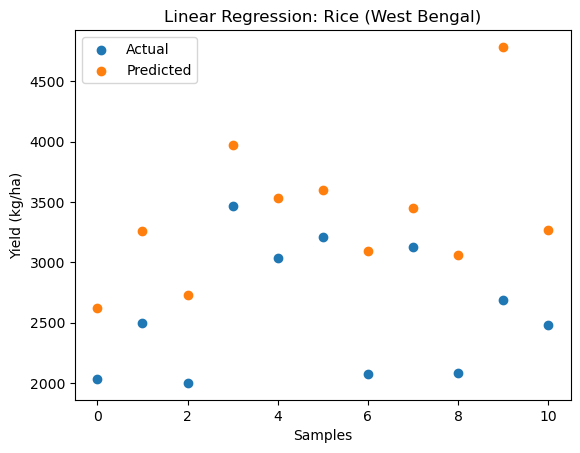

In [15]:
actual_lr = y_test[mask]
pred_lr = y_pred_lr[mask]

plot_model(actual_lr, pred_lr, "Linear Regression: Rice (West Bengal)")

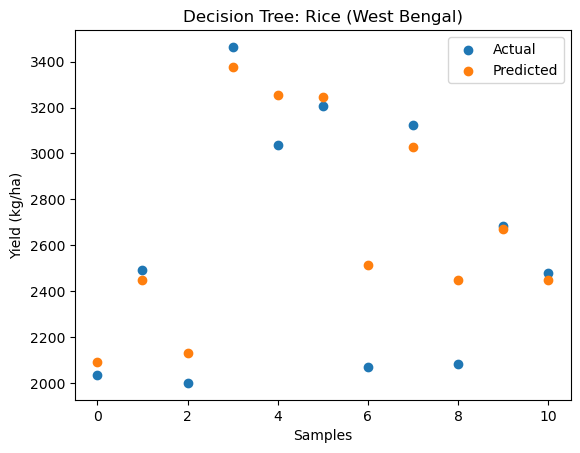

In [16]:
actual_dt = y_test[mask]
pred_dt = y_pred_dt[mask]

plot_model(actual_dt, pred_dt, "Decision Tree: Rice (West Bengal)")

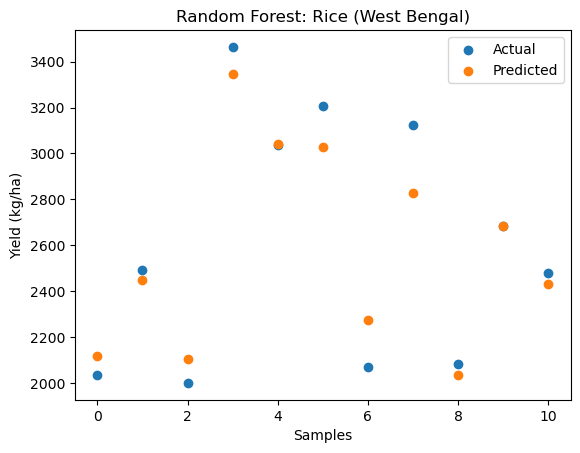

In [17]:
actual_rf = y_test[mask]
pred_rf = y_pred_rf[mask]

plot_model(actual_rf, pred_rf, "Random Forest: Rice (West Bengal)")

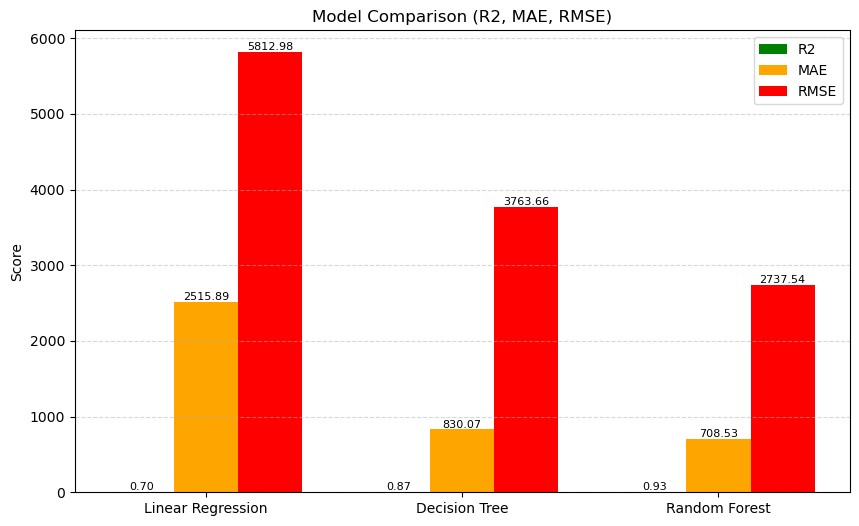

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Model names
models = ['Linear Regression', 'Decision Tree', 'Random Forest']

# Metrics
r2 = [r2_lr, r2_dt, r2_rf]
mae = [mae_lr, mae_dt, mae_rf]
rmse = [rmse_lr, rmse_dt, rmse_rf]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))

# Bars
bars1 = plt.bar(x - width, r2, width, label='R2', color='green')
bars2 = plt.bar(x, mae, width, label='MAE', color='orange')
bars3 = plt.bar(x + width, rmse, width, label='RMSE', color='red')

# Labels
plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Comparison (R2, MAE, RMSE)")
plt.legend()

# Value labels
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height,
                 f'{height:.2f}',
                 ha='center', va='bottom', fontsize=8)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [24]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 4.7/101.7 MB 29.0 MB/s eta 0:00:04
   --- ------------------------------------ 9.4/101.7 MB 29.4 MB/s eta 0:00:04
   --- ------------------------------------ 9.4/101.7 MB 29.4 MB/s eta 0:00:04
   ----- ---------------------------------- 15.2/101.7 MB 19.0 MB/s eta 0:00:05
   ------- -------------------------------- 17.8/101.7 MB 20.9 MB/s eta 0:00:05
   -------- ------------------------------- 22.0/101.7 MB 18.0 MB/s eta 0:00:05
   ---------- ----------------------------- 26.2/101.7 MB 19.9 MB/s eta 0:00:04
   ----------- ---------------------------- 28.3/101.7 MB 18.7 MB/s eta 0:00:04
   ----------- ---------------------------- 28.6/101.7 MB 15.4 MB/s eta 0:00:05
   -------------- ------------------------- 38.0/101.7 MB 18.5 MB/s eta 0:00:04
   ------------------ --------------------- 46.1/101.7 MB 20.4 MB/s eta 0:00:03
   ---------------------- ----------------- 56.1/101


XGBOOST
MAE: 878.1250717079295
MSE: 8054312.270368349
RMSE: 2838.0120278759123
R2: 0.9285736889803556


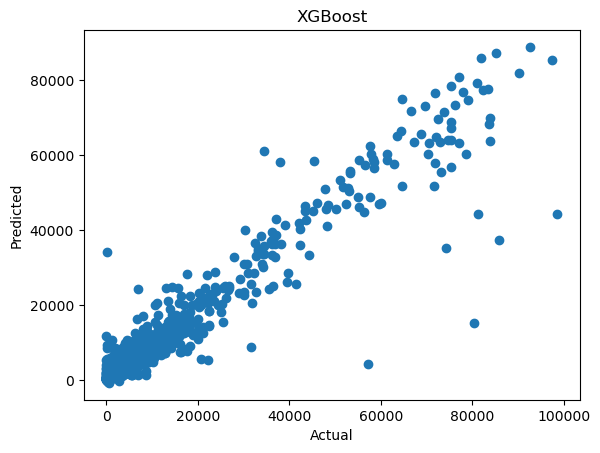

In [27]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# 🔹 Model
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# 🔹 Train
xgb.fit(X_train, y_train)

# 🔹 Predict
y_pred_xgb = xgb.predict(X_test)

# 🔹 Metrics
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\nXGBOOST")
print("MAE:", mae_xgb)
print("MSE:", mse_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

# 🔹 Excel
xgb_df = X_test.copy()
xgb_df['Actual_Yield'] = y_test
xgb_df['Predicted_XGB'] = y_pred_xgb
xgb_df.to_excel("XGBoost_Output.xlsx", index=False)

# 🔹 Graph
plt.scatter(y_test, y_pred_xgb)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("XGBoost")
plt.show()

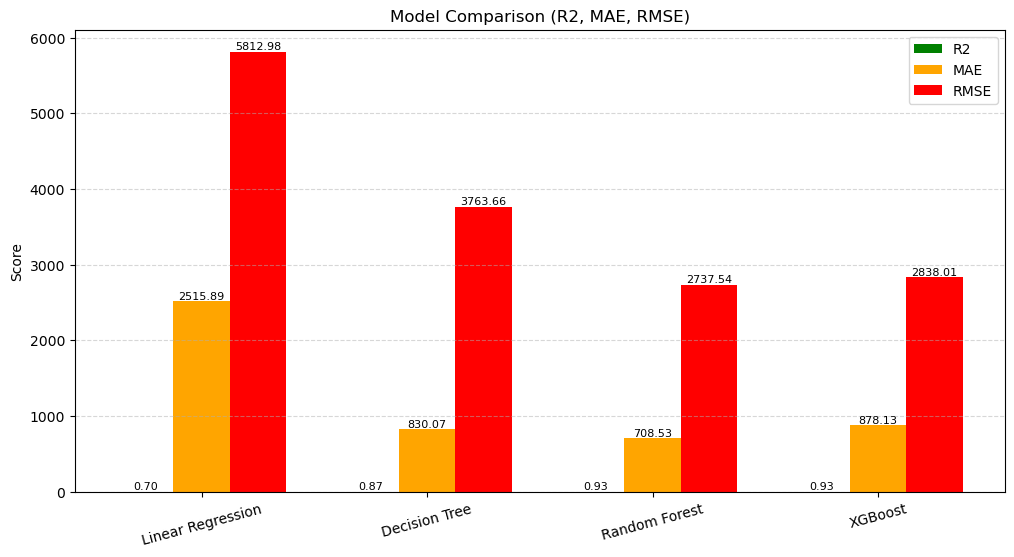

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# 🔹 Model names (XGBoost add kiya)
models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost']

# 🔹 Metrics (XGBoost add kiya)
r2 = [r2_lr, r2_dt, r2_rf, r2_xgb]
mae = [mae_lr, mae_dt, mae_rf, mae_xgb]
rmse = [rmse_lr, rmse_dt, rmse_rf, rmse_xgb]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(12,6))

# 🔹 Bars
bars1 = plt.bar(x - width, r2, width, label='R2', color='green')
bars2 = plt.bar(x, mae, width, label='MAE', color='orange')
bars3 = plt.bar(x + width, rmse, width, label='RMSE', color='red')

# 🔹 Labels
plt.xticks(x, models, rotation=15)
plt.ylabel("Score")
plt.title("Model Comparison (R2, MAE, RMSE)")
plt.legend()

# 🔹 Value labels
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height,
                 f'{height:.2f}',
                 ha='center', va='bottom', fontsize=8)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

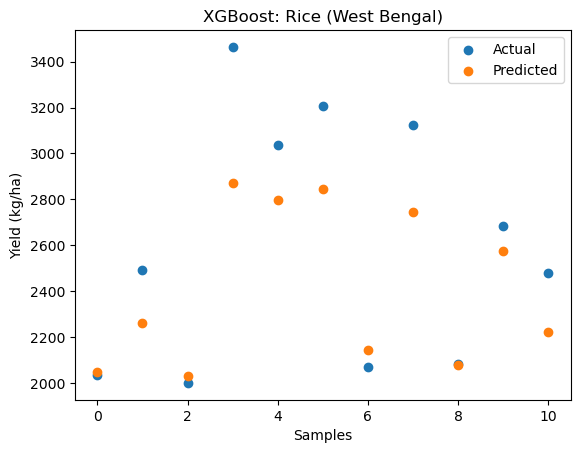

In [29]:
actual_xgb = y_test[mask]
pred_xgb = y_pred_xgb[mask]

plot_model(actual_xgb, pred_xgb, "XGBoost: Rice (West Bengal)")